# Speech-Based Depression Detection
## Evaluation and Analysis

This notebook evaluates and analyzes the performance of the classical
MFCC + SVM baseline and the CNN-based speech classification model.

### Objectives
- Compare classical ML and deep learning approaches
- Analyze class-wise performance
- Visualize confusion matrices
- Examine training behavior
- Perform error analysis
- Document dataset and model limitations

In [19]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score,
    accuracy_score
)

print("Imports successful!")

Imports successful!


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
DATASET_PATH = "/content/drive/MyDrive/bio-cas-2024-depression-detection-grand-challenge"

TRAIN_AUDIO_PATH = os.path.join(
    DATASET_PATH,
    "train"
)

FEATURE_DIR = os.path.join(
    DATASET_PATH,
    "processed_features"
)

print("Setup complete.")

Setup complete.


In [16]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cpu


In [17]:
train_df = pd.read_csv(
    os.path.join(
        DATASET_PATH,
        "Train.csv"
    )
)

train_df["audio_path"] = train_df["File_name"].apply(
    lambda x: os.path.join(
        TRAIN_AUDIO_PATH,
        x
    )
)

print("Total participants:", len(train_df))

Total participants: 89


In [20]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_indices, val_indices = next(
    skf.split(
        train_df,
        train_df["Label"]
    )
)

val_participants = train_df.iloc[
    val_indices
].copy()

print(
    "Validation participants:",
    len(val_participants)
)

print("\nValidation labels:")
print(
    val_participants["Label"]
    .value_counts()
    .sort_index()
)

Validation participants: 18

Validation labels:
Label
0    8
1    1
2    6
3    3
Name: count, dtype: int64


In [21]:
class SpeechCNN(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


print("CNN architecture defined.")

CNN architecture defined.


In [22]:
model = SpeechCNN(num_classes=4).to(device)

model_path = os.path.join(
    FEATURE_DIR,
    "cnn_best_depression.pth"
)

model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model.eval()

print("Trained CNN loaded successfully.")

Trained CNN loaded successfully.


In [23]:
TARGET_SR = 16000
SEGMENT_DURATION = 5
SEGMENT_SAMPLES = TARGET_SR * SEGMENT_DURATION

N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256

print("Audio preprocessing settings ready.")

Audio preprocessing settings ready.


In [24]:
def audio_to_logmel(audio_segment, sr=16000):
    mel = librosa.feature.melspectrogram(
        y=audio_segment,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    log_mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return log_mel


print("Log-Mel function defined.")

Log-Mel function defined.


In [25]:
from torch.utils.data import Dataset, DataLoader


class ValidationSpeechDataset(Dataset):

    def __init__(
        self,
        dataframe,
        sr=16000,
        segment_duration=5
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.sr = sr
        self.segment_samples = sr * segment_duration

        self.segments = []

        print("Preparing validation dataset...")

        for _, row in self.dataframe.iterrows():

            audio_path = row["audio_path"]
            label = int(row["Label"])
            participant = row["Participant"]

            audio, _ = librosa.load(
                audio_path,
                sr=sr,
                mono=True
            )

            num_segments = len(audio) // self.segment_samples

            for segment_idx in range(num_segments):

                start = segment_idx * self.segment_samples
                end = start + self.segment_samples

                segment = audio[start:end]

                log_mel = audio_to_logmel(
                    segment,
                    sr=sr
                )

                self.segments.append({
                    "participant": participant,
                    "label": label,
                    "log_mel": log_mel
                })

        print(
            f"Participants: {len(self.dataframe)} | "
            f"Segments: {len(self.segments)}"
        )

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, index):

        item = self.segments[index]

        log_mel = torch.tensor(
            item["log_mel"],
            dtype=torch.float32
        )

        log_mel = log_mel.unsqueeze(0)

        label = torch.tensor(
            item["label"],
            dtype=torch.long
        )

        participant = item["participant"]

        return log_mel, label, participant

In [26]:
val_dataset = ValidationSpeechDataset(
    val_participants
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("Validation DataLoader ready.")

Preparing validation dataset...


/tmp/ipykernel_2183/1896525825.py:26: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_2183/1896525825.py:26: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_2183/1896525825.py:26: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.

Participants: 18 | Segments: 1203
Validation DataLoader ready.


In [27]:
def evaluate_participant_level(model, loader, device):

    model.eval()

    participant_probs = {}
    participant_labels = {}

    with torch.no_grad():

        for X, y_batch, participants in loader:

            X = X.to(device)

            outputs = model(X)

            probs = torch.softmax(
                outputs,
                dim=1
            )

            probs = probs.cpu().numpy()
            y_batch = y_batch.numpy()

            for prob, label, participant in zip(
                probs,
                y_batch,
                participants
            ):

                if participant not in participant_probs:
                    participant_probs[participant] = []

                participant_probs[participant].append(prob)
                participant_labels[participant] = int(label)

    y_true = []
    y_pred = []

    for participant in participant_probs:

        avg_prob = np.mean(
            participant_probs[participant],
            axis=0
        )

        prediction = np.argmax(avg_prob)

        y_true.append(
            participant_labels[participant]
        )

        y_pred.append(prediction)

    return y_true, y_pred, participant_probs

In [28]:
y_true, y_pred, participant_probs = evaluate_participant_level(
    model,
    val_loader,
    device
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

print("Evaluation Results")
print("-" * 30)
print("Participants evaluated:", len(y_true))
print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced Accuracy:", round(balanced_acc, 4))

Evaluation Results
------------------------------
Participants evaluated: 17
Accuracy: 0.5882
Macro F1: 0.4762
Balanced Accuracy: 0.4286


In [29]:
print(
    classification_report(
        y_true,
        y_pred,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     1.0000    0.7143    0.8333         7
           1     0.0000    0.0000    0.0000         1
           2     0.5000    0.6667    0.5714         6
           3     1.0000    0.3333    0.5000         3

    accuracy                         0.5882        17
   macro avg     0.6250    0.4286    0.4762        17
weighted avg     0.7647    0.5882    0.6331        17



Confusion Matrix:
[[5 1 1 0]
 [0 0 1 0]
 [0 2 4 0]
 [0 0 2 1]]


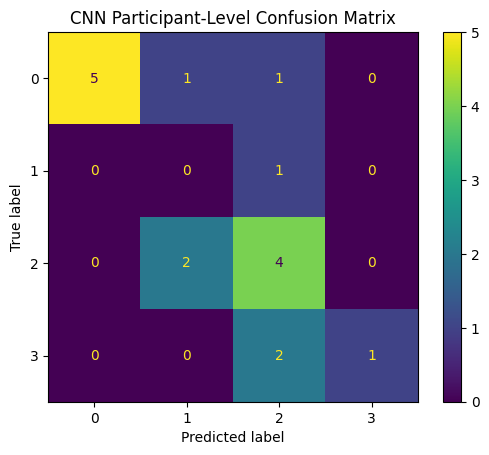

In [30]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3]
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3]
)

disp.plot()
plt.title("CNN Participant-Level Confusion Matrix")
plt.show()

In [31]:
class_f1 = f1_score(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
    average=None,
    zero_division=0
)

class_f1_df = pd.DataFrame({
    "Label": [0, 1, 2, 3],
    "F1 Score": class_f1
})

print(class_f1_df)

   Label  F1 Score
0      0  0.833333
1      1  0.000000
2      2  0.571429
3      3  0.500000


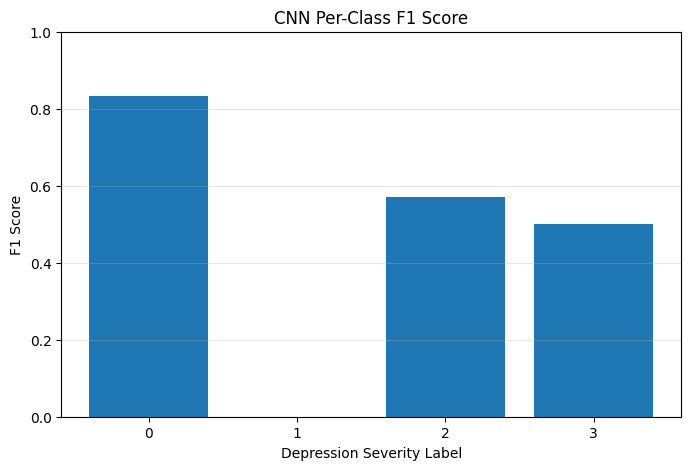

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_f1_df["Label"].astype(str),
    class_f1_df["F1 Score"]
)

plt.xlabel("Depression Severity Label")
plt.ylabel("F1 Score")
plt.title("CNN Per-Class F1 Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [33]:
comparison_df = pd.DataFrame({
    "Model": [
        "MFCC + SVM",
        "Log-Mel + CNN"
    ],
    "Representation": [
        "MFCC",
        "Log-Mel Spectrogram"
    ],
    "Macro F1": [
        0.3529,
        macro_f1
    ],
    "Balanced Accuracy": [
        0.3518,
        balanced_acc
    ]
})

comparison_df

,Model,Representation,Macro F1,Balanced Accuracy
0,MFCC + SVM,MFCC,0.35290,0.351800
1,Log-Mel + CNN,Log-Mel Spectrogram,0.47619,0.428571


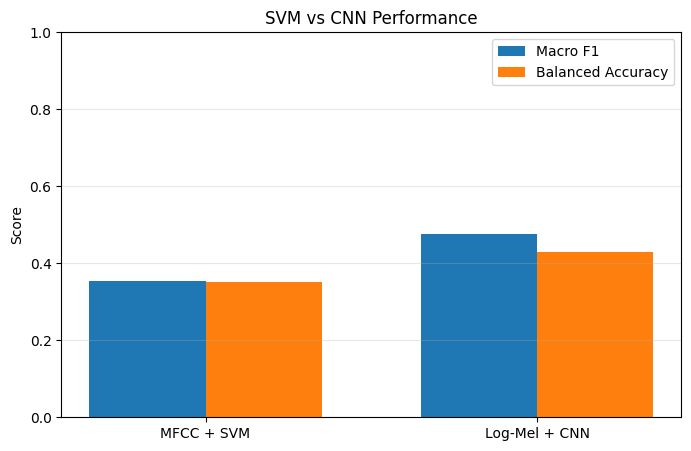

In [34]:
plt.figure(figsize=(8, 5))

x = np.arange(len(comparison_df))
width = 0.35

plt.bar(
    x - width/2,
    comparison_df["Macro F1"],
    width,
    label="Macro F1"
)

plt.bar(
    x + width/2,
    comparison_df["Balanced Accuracy"],
    width,
    label="Balanced Accuracy"
)

plt.xticks(
    x,
    comparison_df["Model"]
)

plt.ylabel("Score")
plt.title("SVM vs CNN Performance")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [35]:
improvement = (
    (macro_f1 - 0.3529) / 0.3529
) * 100

print("Key Findings")
print("-" * 40)

print(
    f"CNN Macro F1: {macro_f1:.4f}"
)

print(
    f"SVM Macro F1: 0.3529"
)

print(
    f"Macro F1 improvement: {improvement:.2f}%"
)

print(
    f"CNN Balanced Accuracy: {balanced_acc:.4f}"
)

print(
    f"SVM Balanced Accuracy: 0.3518"
)

Key Findings
----------------------------------------
CNN Macro F1: 0.4762
SVM Macro F1: 0.3529
Macro F1 improvement: 34.94%
CNN Balanced Accuracy: 0.4286
SVM Balanced Accuracy: 0.3518


## Key Findings
----------------------------------------
CNN Macro F1: 0.4762
SVM Macro F1: 0.3529
Macro F1 improvement: 34.94%
CNN Balanced Accuracy: 0.4286
SVM Balanced Accuracy: 0.3518